# CO2 Emission by Vehicles

## <b><font color='red'> Business Objective </font></b>
- ##### The fundamental goal here is to model the CO2 emissions as a function of several car engines features.

## <b><font color='red'> Data Set Details </font></b>

#### The file contains the data for this example. Here the number of variables (columns) is 12, and the number of instances (rows) is 7385. In that way, this problem has the 12 following variables:
- ##### make, car brand under study.
- ##### model, the specific model of the car.
- ##### vehicle_class, car body type of the car.
- ##### engine_size, size of the car engine, in Litres.
- ##### cylinders, number of cylinders.
- ##### transmission, "A" for 'Automatic', "AM" for 'Automated manual', "AS" for 'Automatic with select shift', "AV" for 'Continuously variable', "M" for 'Manual'.
- ##### fuel_type, "X" for 'Regular gasoline', "Z" for 'Premium gasoline', "D" for 'Diesel', "E" for 'Ethanol (E85)', "N" for 'Natural gas'.
- ##### fuel_consumption_city, City fuel consumption ratings, in litres per 100 kilometres.
- ##### fuel_consumption_hwy, Highway fuel consumption ratings, in litres per 100 kilometres.
- ##### fuel_consumption_comb(l/100km), the combined fuel consumption rating (55% city, 45% highway), in L/100 km.
- ##### fuel_consumption_comb(mpg), the combined fuel consumption rating (55% city, 45% highway), in miles per gallon (mpg).
- ##### co2_emissions, the tailpipe emissions of carbon dioxide for combined city and highway driving, in grams per kilometer.


### <font color='green'> Importing some important libraries </font>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## <font color='green'> EDA (Exploratory Data Analysis)</font>

In [ ]:
# storing the data into a variable
df = pd.read_csv('/content/CO2 Emissions_Canada.csv')

In [ ]:
#check first 10 records
df.head(10)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
6,ACURA,TL,MID-SIZE,3.5,6,AS6,Z,11.8,8.1,10.1,28,232
7,ACURA,TL AWD,MID-SIZE,3.7,6,AS6,Z,12.8,9.0,11.1,25,255
8,ACURA,TL AWD,MID-SIZE,3.7,6,M6,Z,13.4,9.5,11.6,24,267
9,ACURA,TSX,COMPACT,2.4,4,AS5,Z,10.6,7.5,9.2,31,212


In [ ]:
#check last 10 records
df.tail()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7384,VOLVO,XC90 T6 AWD,SUV - STANDARD,2.0,4,AS8,Z,12.2,8.7,10.7,26,248


In [ ]:
#checking the null values
df.isnull().sum()

,0
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


##### We can say there is no null values is present in out data set.

In [ ]:
# collecting the information about the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [ ]:
#checking the shape of the data set
df.shape

(7385, 12)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),7385.0,3.160068,1.354170,0.9,2.0,3.0,3.7,8.4
Cylinders,7385.0,5.615030,1.828307,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),7385.0,12.556534,3.500274,4.2,10.1,12.1,14.6,30.6
Fuel Consumption Hwy (L/100 km),7385.0,9.041706,2.224456,4.0,7.5,8.7,10.2,20.6
Fuel Consumption Comb (L/100 km),7385.0,10.975071,2.892506,4.1,8.9,10.6,12.6,26.1
Fuel Consumption Comb (mpg),7385.0,27.481652,7.231879,11.0,22.0,27.0,32.0,69.0
CO2 Emissions(g/km),7385.0,250.584699,58.512679,96.0,208.0,246.0,288.0,522.0


In [ ]:
# checking duplicate values
df.duplicated().sum()

np.int64(1103)

In [ ]:
# droping all the duplicate values
df.drop_duplicates(inplace=True)

In [ ]:
len(df)

6282

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),6282.0,3.161812,1.365201,0.9,2.0,3.0,3.7,8.4
Cylinders,6282.0,5.618911,1.846250,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),6282.0,12.610220,3.553066,4.2,10.1,12.1,14.7,30.6
Fuel Consumption Hwy (L/100 km),6282.0,9.070583,2.278884,4.0,7.5,8.7,10.3,20.6
Fuel Consumption Comb (L/100 km),6282.0,11.017876,2.946876,4.1,8.9,10.6,12.7,26.1
Fuel Consumption Comb (mpg),6282.0,27.411016,7.245318,11.0,22.0,27.0,32.0,69.0
CO2 Emissions(g/km),6282.0,251.157752,59.290426,96.0,208.0,246.0,289.0,522.0


In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## <font color='red'>Visualization</font>

### <font color='green'> Brands of Cars </font>

In [ ]:
print("We have total",len(df['Make'].unique()),"Car Companies Data")
df_brand = df['Make'].value_counts().reset_index().rename(columns={'count':'Count'})
df_brand.head(20)

We have total 42 Car Companies Data


,Make,Count
0,FORD,577
1,CHEVROLET,515
2,BMW,501
3,MERCEDES-BENZ,365
4,PORSCHE,296
5,GMC,289
6,TOYOTA,276
7,AUDI,263
8,NISSAN,213
9,JEEP,200


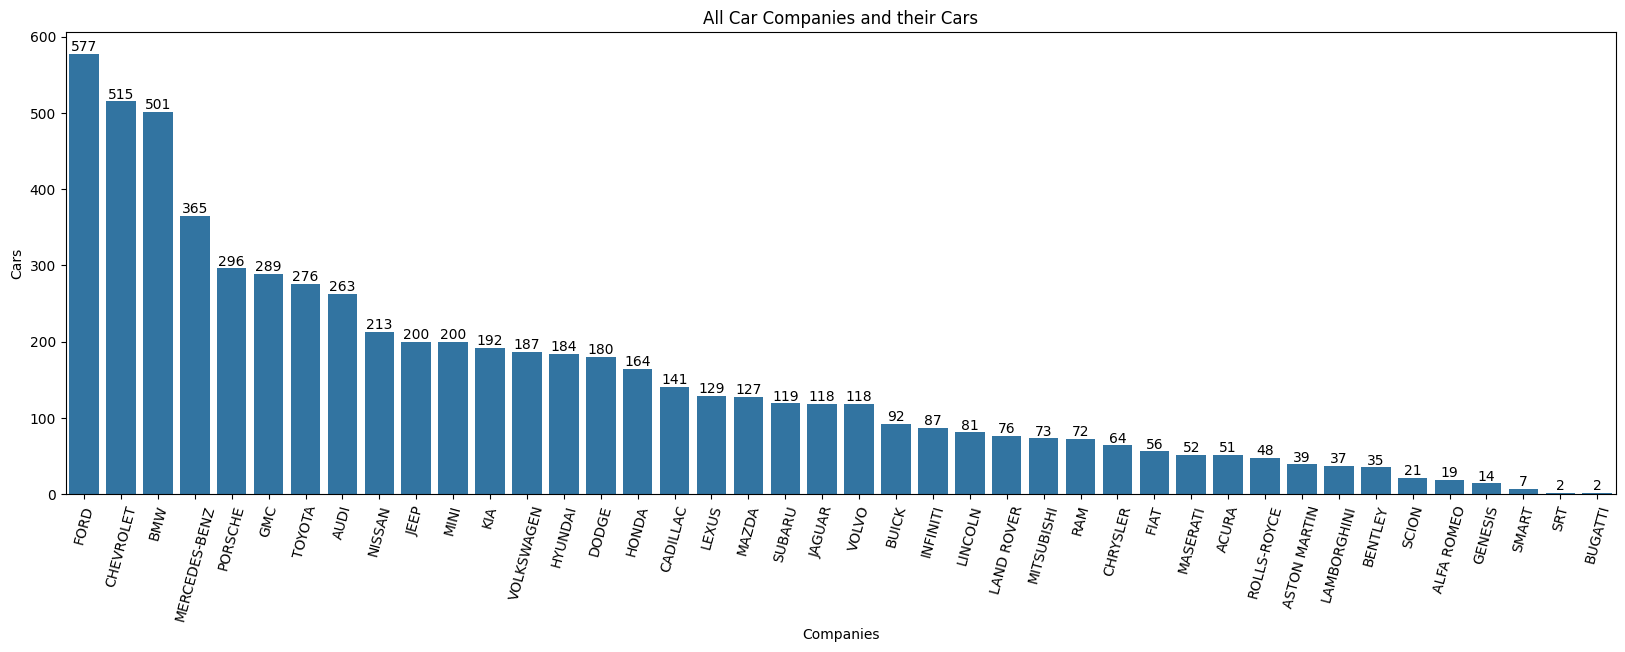

In [ ]:
plt.figure(figsize=(20,6))
figure1 = sns.barplot(data = df_brand, x = "Make",  y= "Count")
plt.xticks(rotation = 75)
plt.title("All Car Companies and their Cars")
plt.xlabel("Companies")
plt.ylabel("Cars")
plt.bar_label(figure1.containers[0])
plt.show()

### <font color=green> Models of cars </font>

In [ ]:
print("We have total",len(df['Model'].unique()),"Car Models")
df_model = df['Model'].value_counts().reset_index().rename(columns={'count':'Count'})[:25]
df_model.head(20)

We have total 2053 Car Models


,Model,Count
0,F-150 FFV,32
1,F-150 FFV 4X4,31
2,MUSTANG,27
3,FOCUS FFV,24
4,F-150 4X4,20
5,F-150,19
6,SONIC 5,18
7,ATS,18
8,COMPASS,18
9,JETTA,18


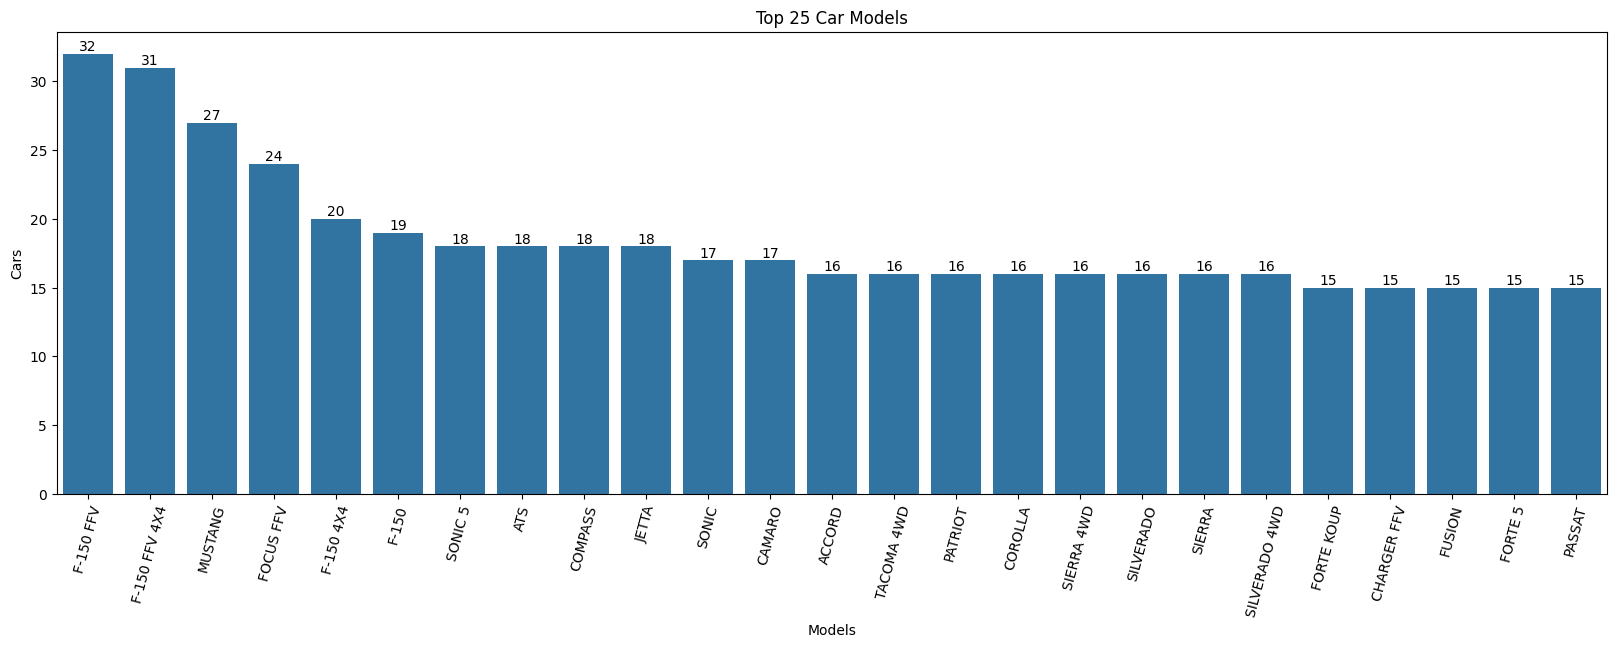

In [ ]:
plt.figure(figsize=(20,6))
figure2 = sns.barplot(data = df_model, x = "Model",  y= "Count")
plt.xticks(rotation = 75)
plt.title("Top 25 Car Models")
plt.xlabel("Models")
plt.ylabel("Cars")
plt.bar_label(figure2.containers[0])
plt.show()

### <font color=green> Vehicle Class </font>

In [ ]:
print("We have total",len(df['Vehicle Class'].unique()),"Vehicle Class")
df_vehicle_class = df['Vehicle Class'].value_counts().reset_index().rename(columns={'count':'Count'})
df_vehicle_class

We have total 16 Vehicle Class


,Vehicle Class,Count
0,SUV - SMALL,1006
1,MID-SIZE,983
2,COMPACT,903
3,SUV - STANDARD,613
4,SUBCOMPACT,533
5,FULL-SIZE,508
6,PICKUP TRUCK - STANDARD,475
7,TWO-SEATER,381
8,MINICOMPACT,274
9,STATION WAGON - SMALL,214


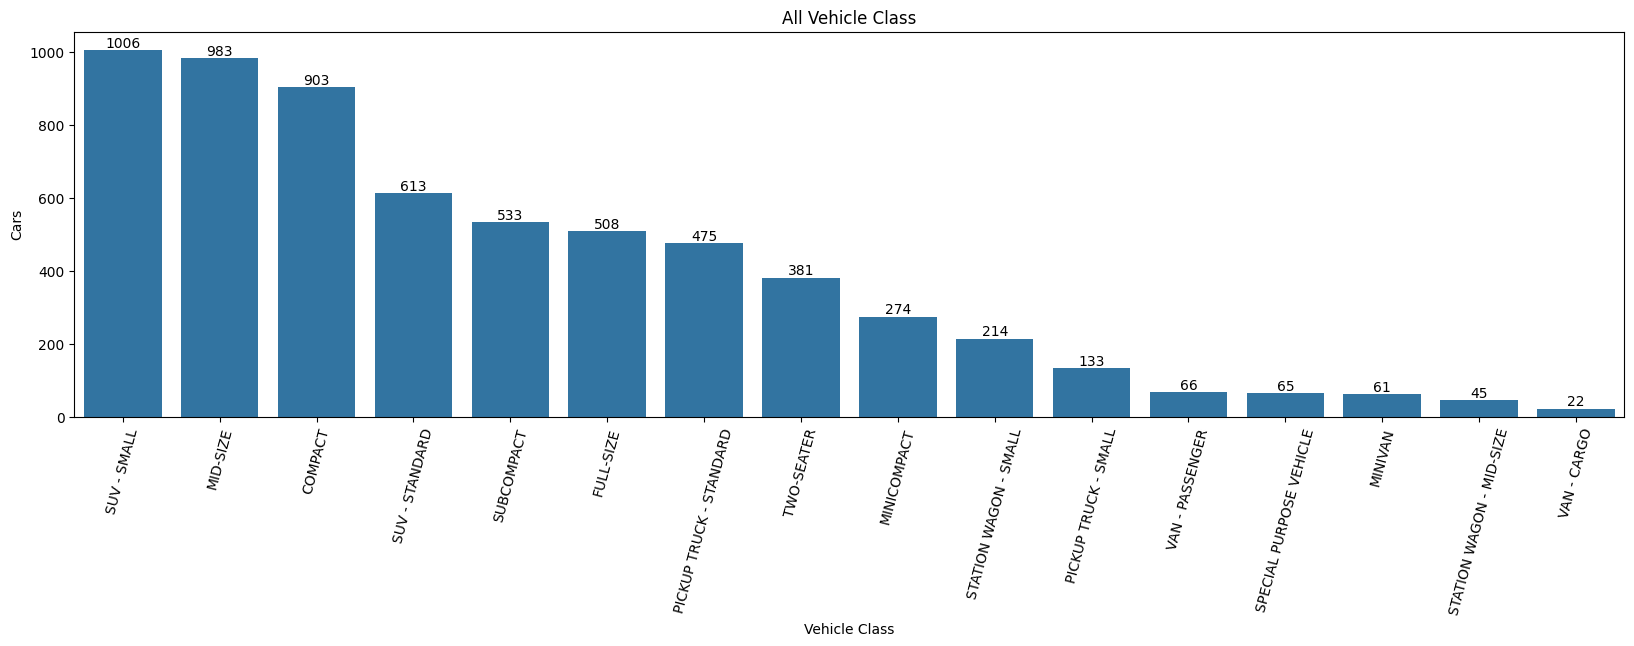

In [ ]:
plt.figure(figsize=(20,5))
figure3 = sns.barplot(data = df_vehicle_class, x = "Vehicle Class",  y= "Count")
plt.xticks(rotation = 75)
plt.title("All Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Cars")
plt.bar_label(figure3.containers[0])
plt.show()

### <font color='green'> Engine Sizes of cars</font>

In [ ]:
print("We have total",len(df['Engine Size(L)'].unique()),"Types of Engine Size")
df_engine_size = df['Engine Size(L)'].value_counts().reset_index().rename(columns={'count':'Count'})
df_engine_size.head(20)

We have total 51 Types of Engine Size


,Engine Size(L),Count
0,2.0,1260
1,3.0,687
2,3.6,433
3,3.5,431
4,2.5,355
5,2.4,287
6,1.6,272
7,5.3,240
8,1.8,191
9,5.0,179


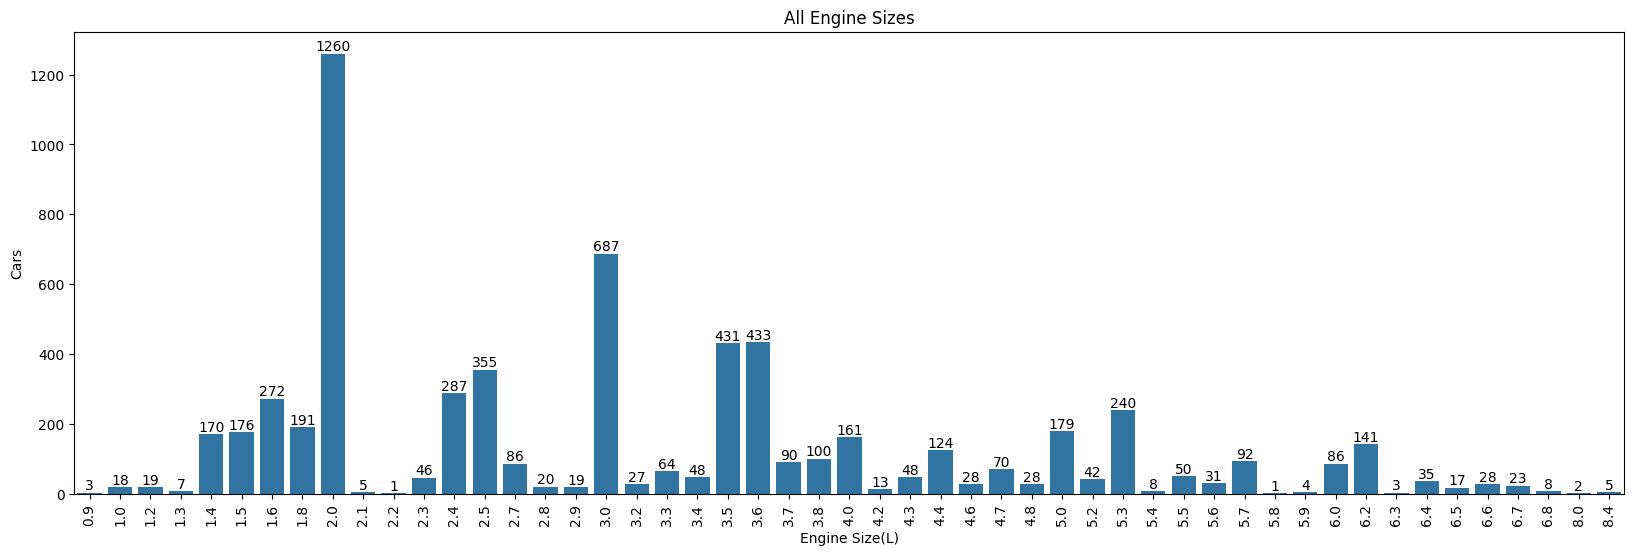

In [ ]:
plt.figure(figsize=(20,6))
figure4 = sns.barplot(data = df_engine_size, x = "Engine Size(L)",  y= "Count")
plt.xticks(rotation = 90)
plt.title("All Engine Sizes")
plt.xlabel("Engine Size(L)")
plt.ylabel("Cars")
plt.bar_label(figure4.containers[0])
plt.show()

### <font color='green'> Cylinders </font>

In [ ]:
print("We have total",len(df['Cylinders'].unique()),"Types of Cylinders")
df_cylinders = df['Cylinders'].value_counts().reset_index().rename(columns={'count':'Count'})
df_cylinders.head(20)

We have total 8 Types of Cylinders


,Cylinders,Count
0,4,2749
1,6,2040
2,8,1202
3,12,135
4,3,88
5,10,40
6,5,26
7,16,2


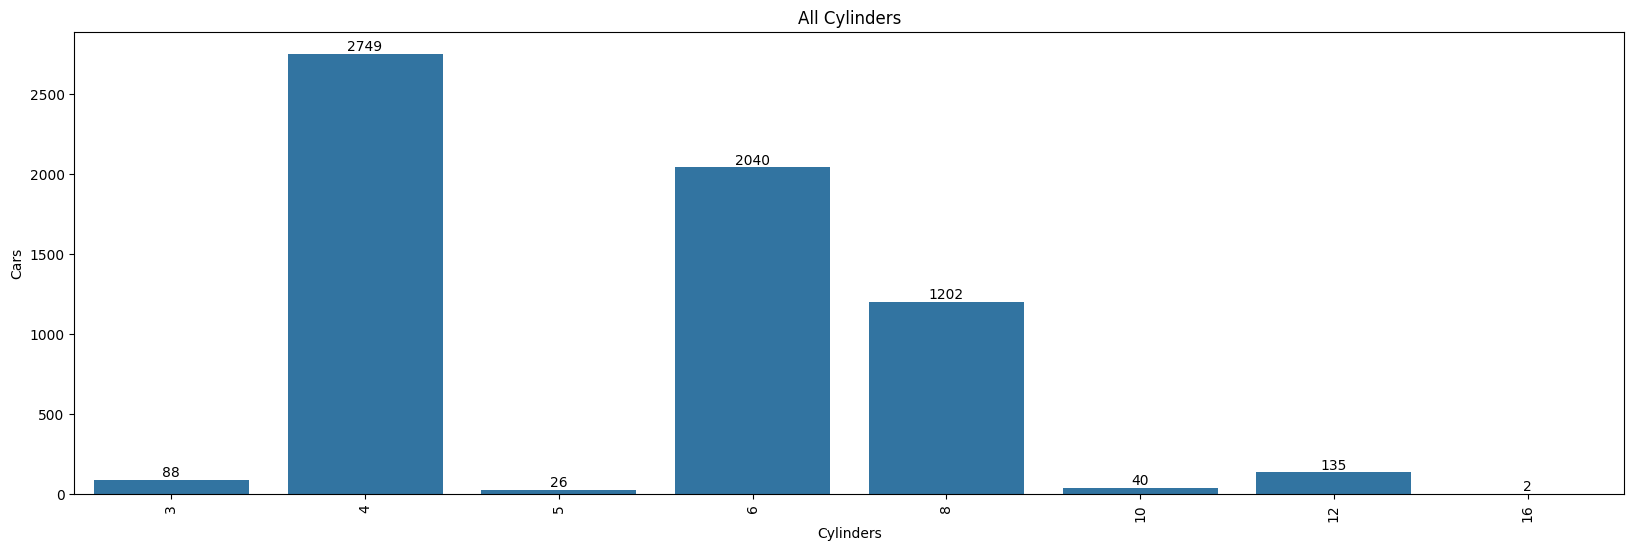

In [ ]:
plt.figure(figsize=(20,6))
figure5 = sns.barplot(data = df_cylinders, x = "Cylinders",  y= "Count")
plt.xticks(rotation = 90)
plt.title("All Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Cars")
plt.bar_label(figure5.containers[0])
plt.show()

### <font color='green'> Transmission of Cars </font>

In [ ]:
df['Transmission'].unique()

array(['AS5', 'M6', 'AV7', 'AS6', 'AM6', 'A6', 'AM7', 'AV8', 'AS8', 'A7',
       'A8', 'M7', 'A4', 'M5', 'AV', 'A5', 'AS7', 'A9', 'AS9', 'AV6',
       'AS4', 'AM5', 'AM8', 'AM9', 'AS10', 'A10', 'AV10'], dtype=object)

#### Here we have to map similar labels into a single label for our Transmission column.

In [ ]:
df["Transmission"] = np.where(df["Transmission"].isin(["A4", "A5", "A6", "A7", "A8", "A9", "A10"]), "Automatic", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["AM5", "AM6", "AM7", "AM8", "AM9"]), "Automated Manual", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["AS4", "AS5", "AS6", "AS7", "AS8", "AS9", "AS10"]), "Automatic with Select Shift", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["AV", "AV6", "AV7", "AV8", "AV10"]), "Continuously Variable", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["M5", "M6", "M7"]), "Manual", df["Transmission"])

In [ ]:
print("We have total",len(df['Transmission'].unique()),"Transmissions")
df_transmission = df['Transmission'].value_counts().reset_index().rename(columns={'count':'Count'})
df_transmission

We have total 5 Transmissions


,Transmission,Count
0,Automatic with Select Shift,2722
1,Automatic,1536
2,Manual,1019
3,Automated Manual,540
4,Continuously Variable,465


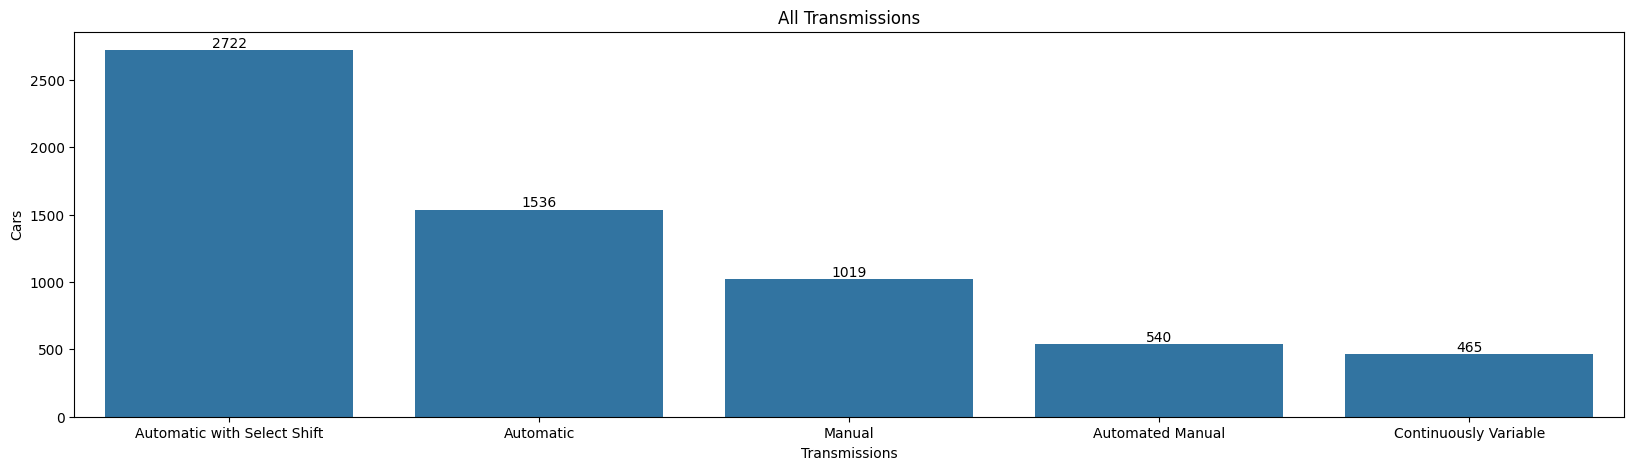

In [ ]:
plt.figure(figsize=(20,5))
figure6 = sns.barplot(data = df_transmission, x = "Transmission",  y= "Count")
plt.title("All Transmissions")
plt.xlabel("Transmissions")
plt.ylabel("Cars")
plt.bar_label(figure6.containers[0])
plt.show()

### <font color='green'> Fuel Type of Cars </font>

In [ ]:
df['Fuel Type'].unique()

array(['Z', 'D', 'X', 'E', 'N'], dtype=object)

#### Here we have to map similar labels into a single label for our Fuel Type column.

In [ ]:
df["Fuel Type"] = np.where(df["Fuel Type"]=="Z", "Premium Gasoline", df["Fuel Type"])
df["Fuel Type"] = np.where(df["Fuel Type"]=="X", "Regular Gasoline", df["Fuel Type"])
df["Fuel Type"] = np.where(df["Fuel Type"]=="D", "Diesel", df["Fuel Type"])
df["Fuel Type"] = np.where(df["Fuel Type"]=="E", "Ethanol(E85)", df["Fuel Type"])
df["Fuel Type"] = np.where(df["Fuel Type"]=="N", "Natural Gas", df["Fuel Type"])

In [ ]:
print("We have total",len(df['Fuel Type'].unique()),"Fuel Types")
df_fuel_type = df['Fuel Type'].value_counts().reset_index().rename(columns={'count':'Count'})
df_fuel_type

We have total 5 Fuel Types


,Fuel Type,Count
0,Regular Gasoline,3039
1,Premium Gasoline,2765
2,Ethanol(E85),330
3,Diesel,147
4,Natural Gas,1


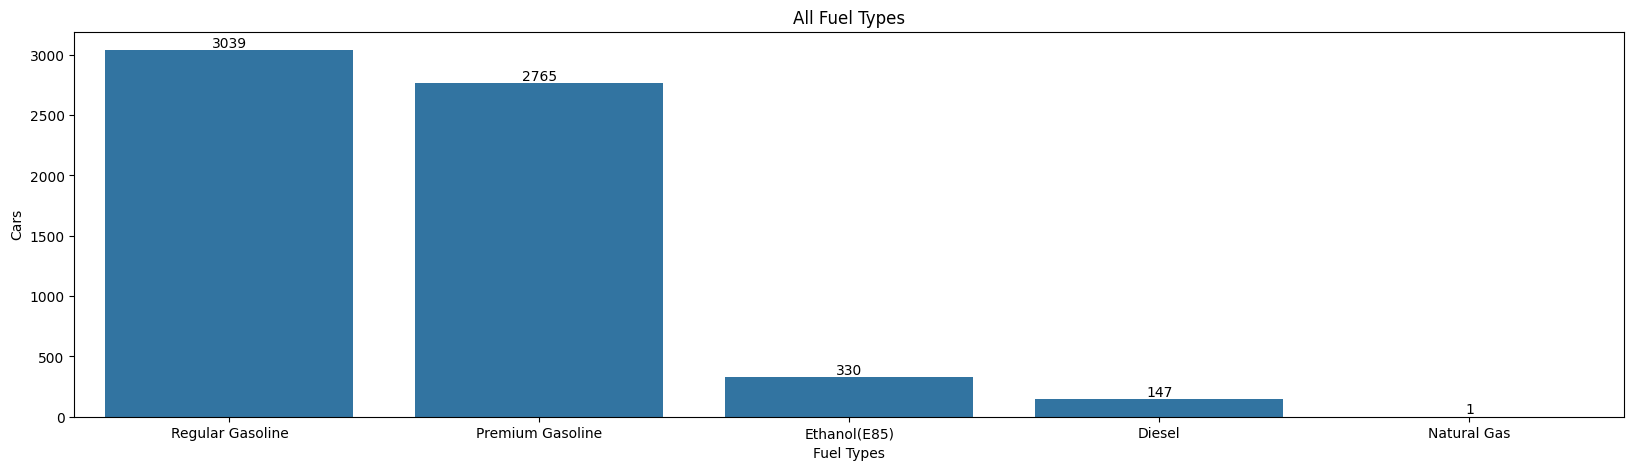

In [ ]:
plt.figure(figsize=(20,5))
figure7 = sns.barplot(data = df_fuel_type, x = "Fuel Type",  y= "Count")
plt.title("All Fuel Types")
plt.xlabel("Fuel Types")
plt.ylabel("Cars")
plt.bar_label(figure7.containers[0])
plt.show()

### <font color='green'> Distplot </font>

<Axes: xlabel='CO2 Emissions(g/km)', ylabel='Density'>

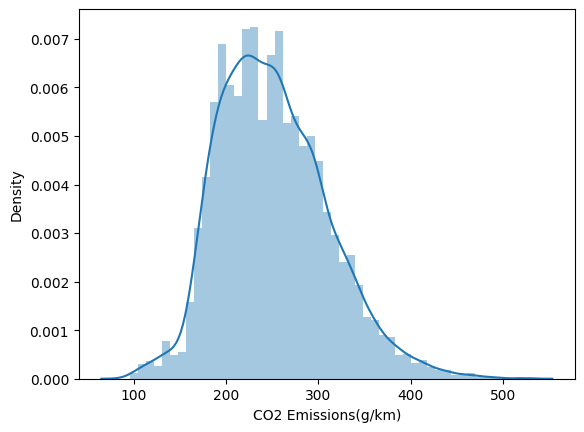

In [ ]:
sns.distplot(df['CO2 Emissions(g/km)'])

<Axes: xlabel='Cylinders', ylabel='Density'>

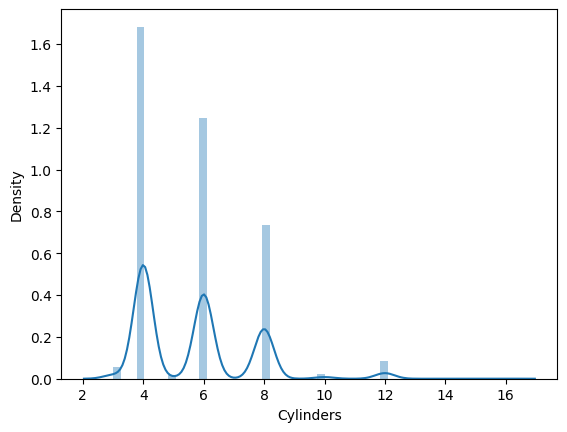

In [ ]:
sns.distplot(df['Cylinders'])

<Axes: xlabel='Engine Size(L)', ylabel='Density'>

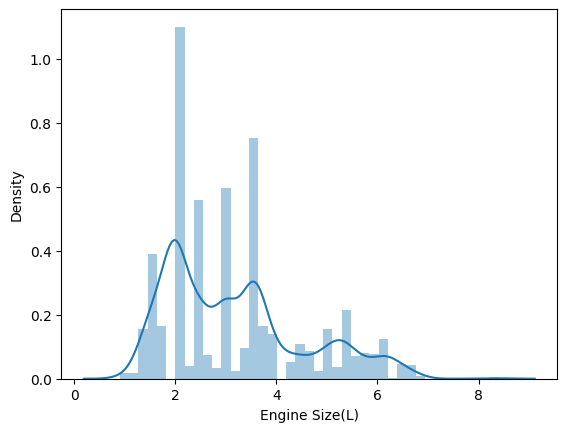

In [ ]:
sns.distplot(df['Engine Size(L)'])

<Axes: xlabel='Fuel Consumption Comb (L/100 km)', ylabel='Density'>

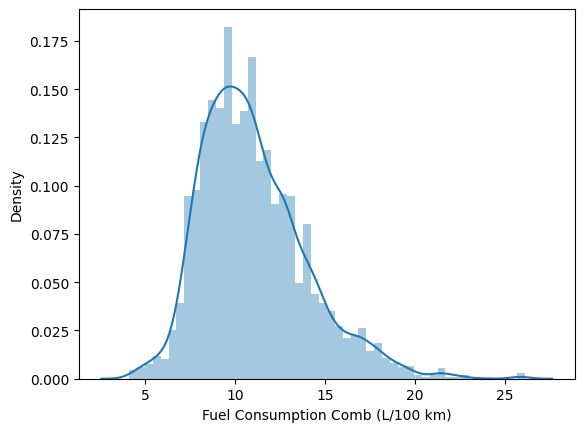

In [ ]:
sns.distplot(df['Fuel Consumption Comb (L/100 km)'])

## <font color='red'>Variation in CO2 emissions with different features.</font>

### <font color='green'> CO2 Emission with Brand </font>

In [ ]:
df_co2_make = df.groupby(['Make'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

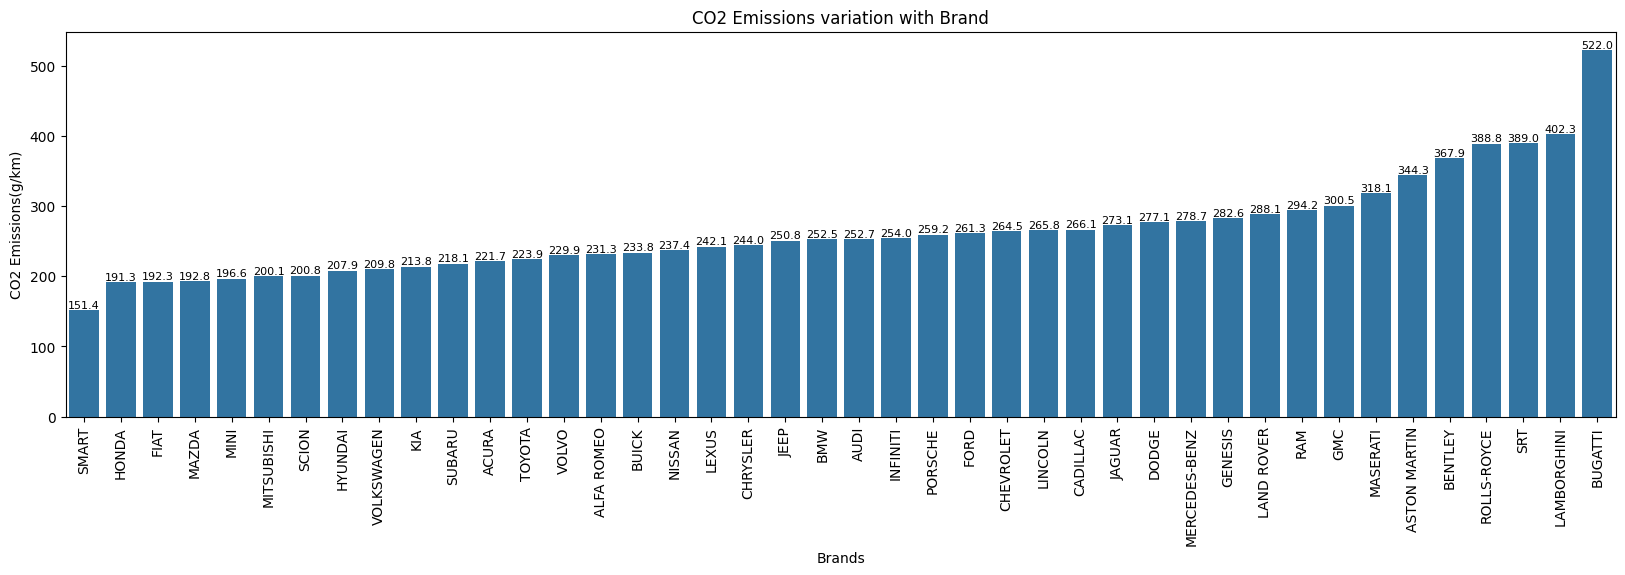

In [ ]:
plt.figure(figsize=(20,5))
figure8 = sns.barplot(data = df_co2_make, x = "Make",  y= "CO2 Emissions(g/km)")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Brand")
plt.xlabel("Brands")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure8.containers[0], fontsize=8, fmt='%.1f')
plt.show()

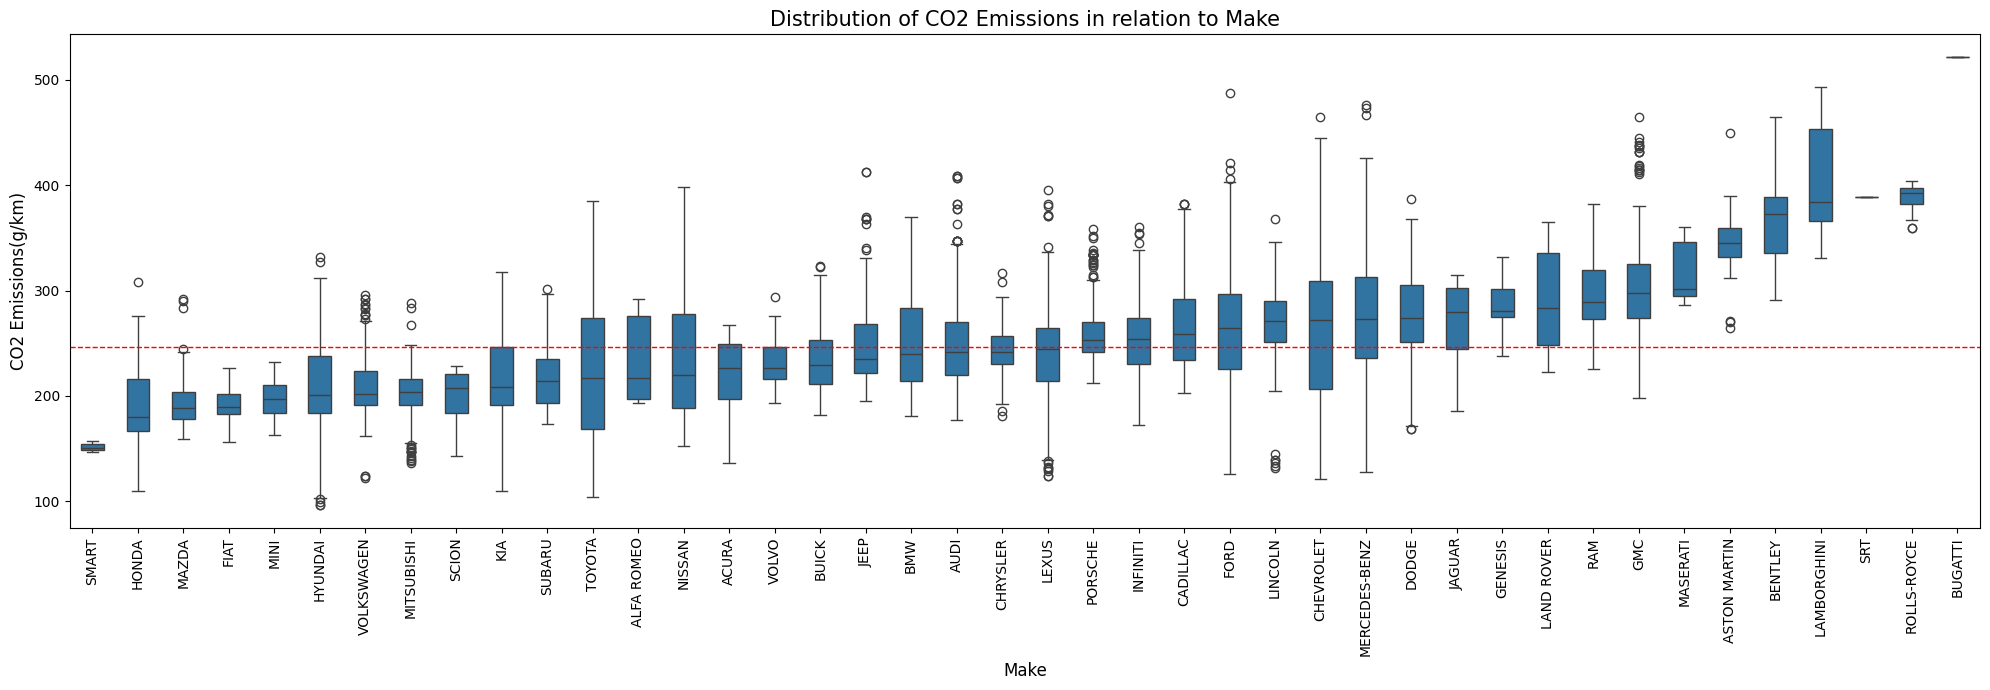

In [ ]:
plt.figure(figsize=(20,7))
order = df.groupby("Make")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Make", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Make", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

### <font color='green'> CO2 Emissions variation with Vehicle Class </font>

In [ ]:
df_co2_vehicle_class = df.groupby(['Vehicle Class'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

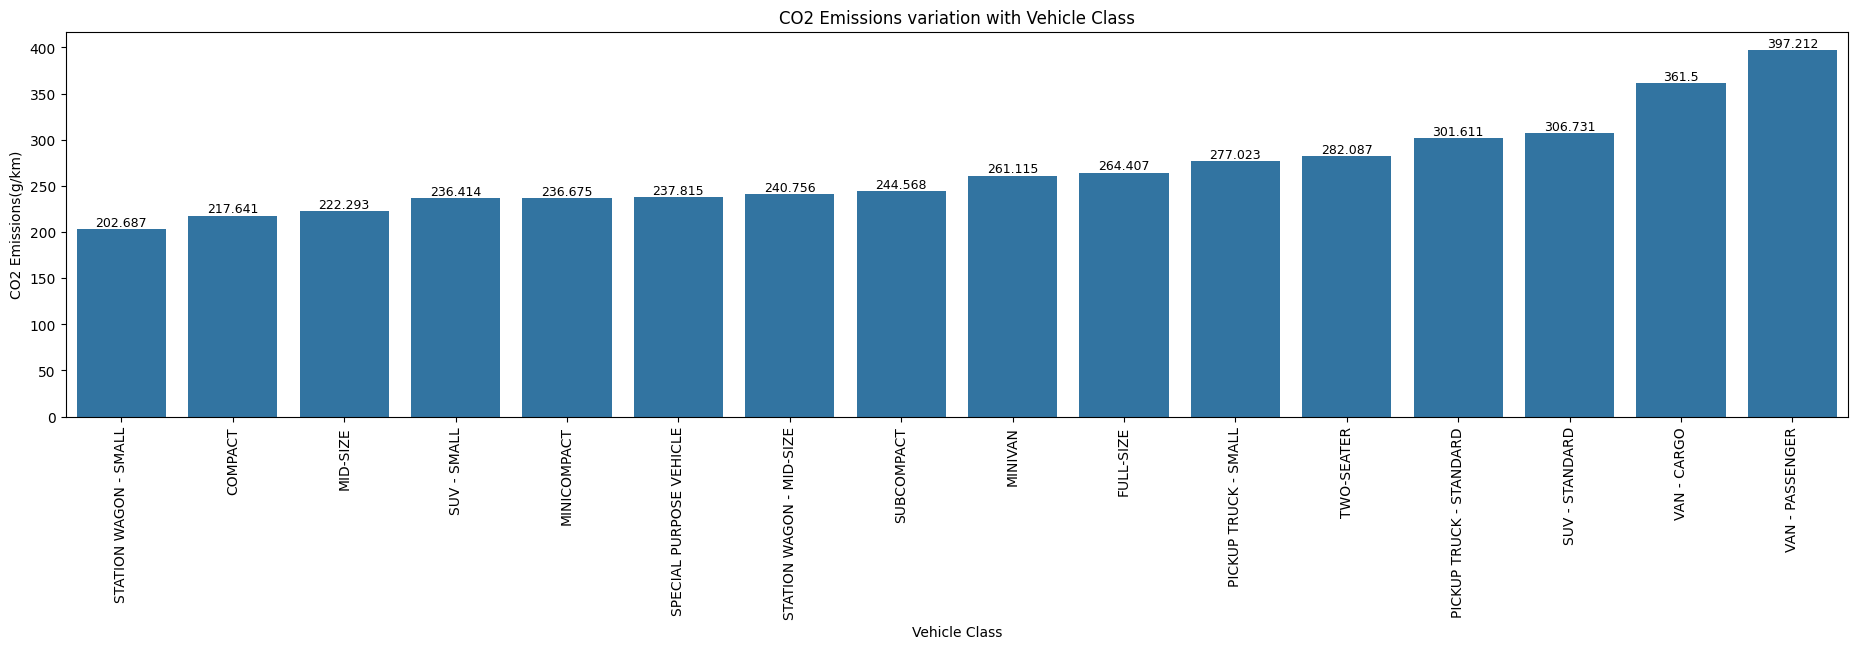

In [ ]:
plt.figure(figsize=(23,5))
figure9 = sns.barplot(data = df_co2_vehicle_class, x = "Vehicle Class",  y= "CO2 Emissions(g/km)")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure9.containers[0], fontsize=9)
plt.show()

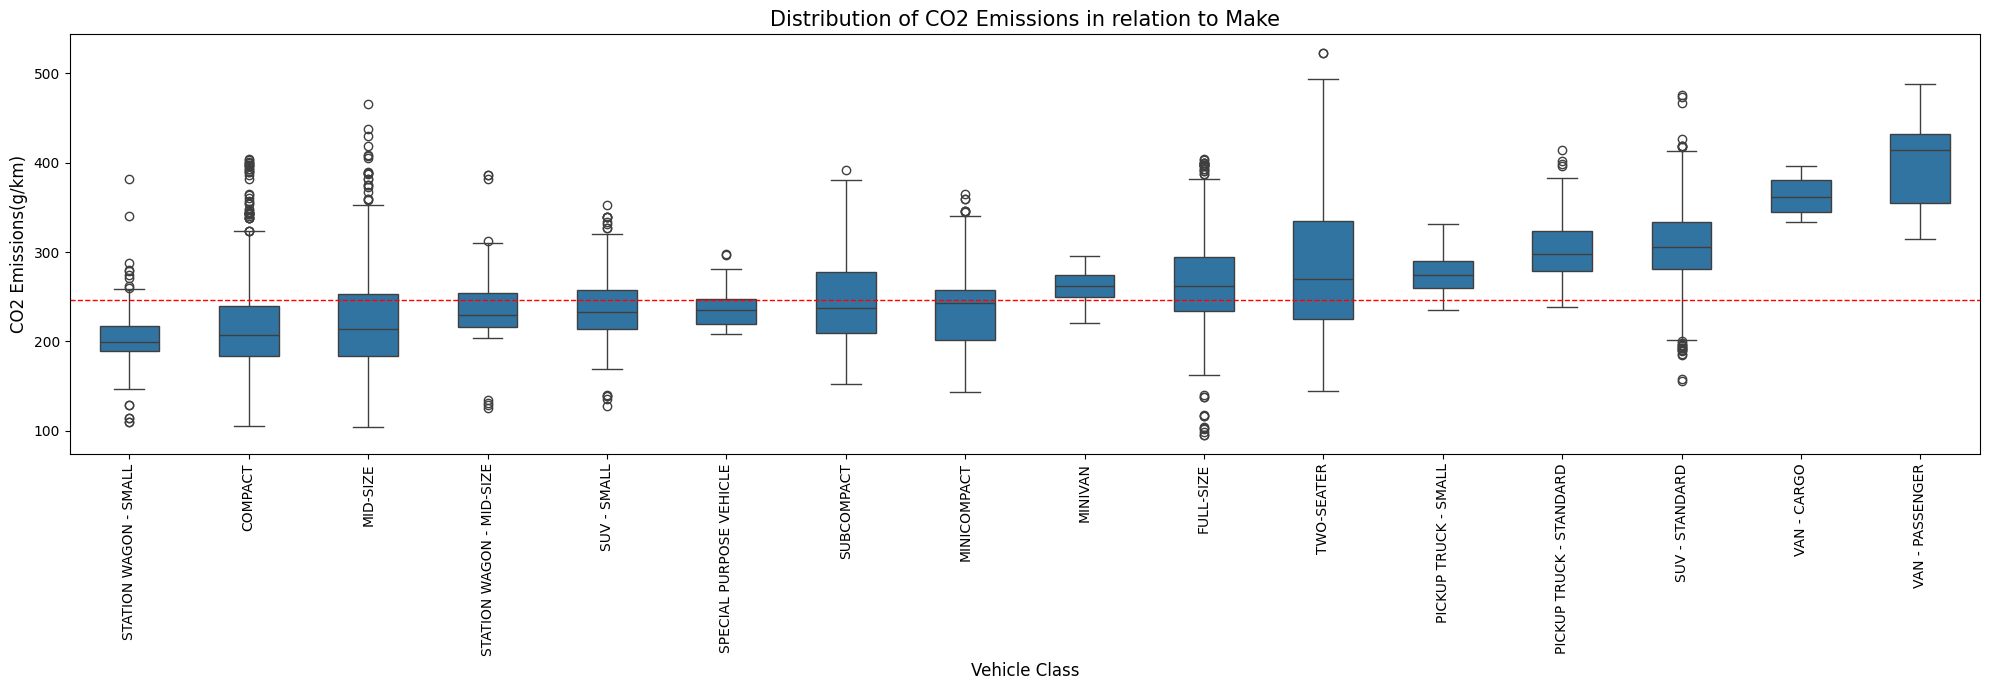

In [ ]:
plt.figure(figsize=(20,7))
order = df.groupby("Vehicle Class")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Vehicle Class", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Vehicle Class", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

### <font color='green'> CO2 Emissions variation with Transmission </font>

In [ ]:
df_co2_transmission = df.groupby(['Transmission'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

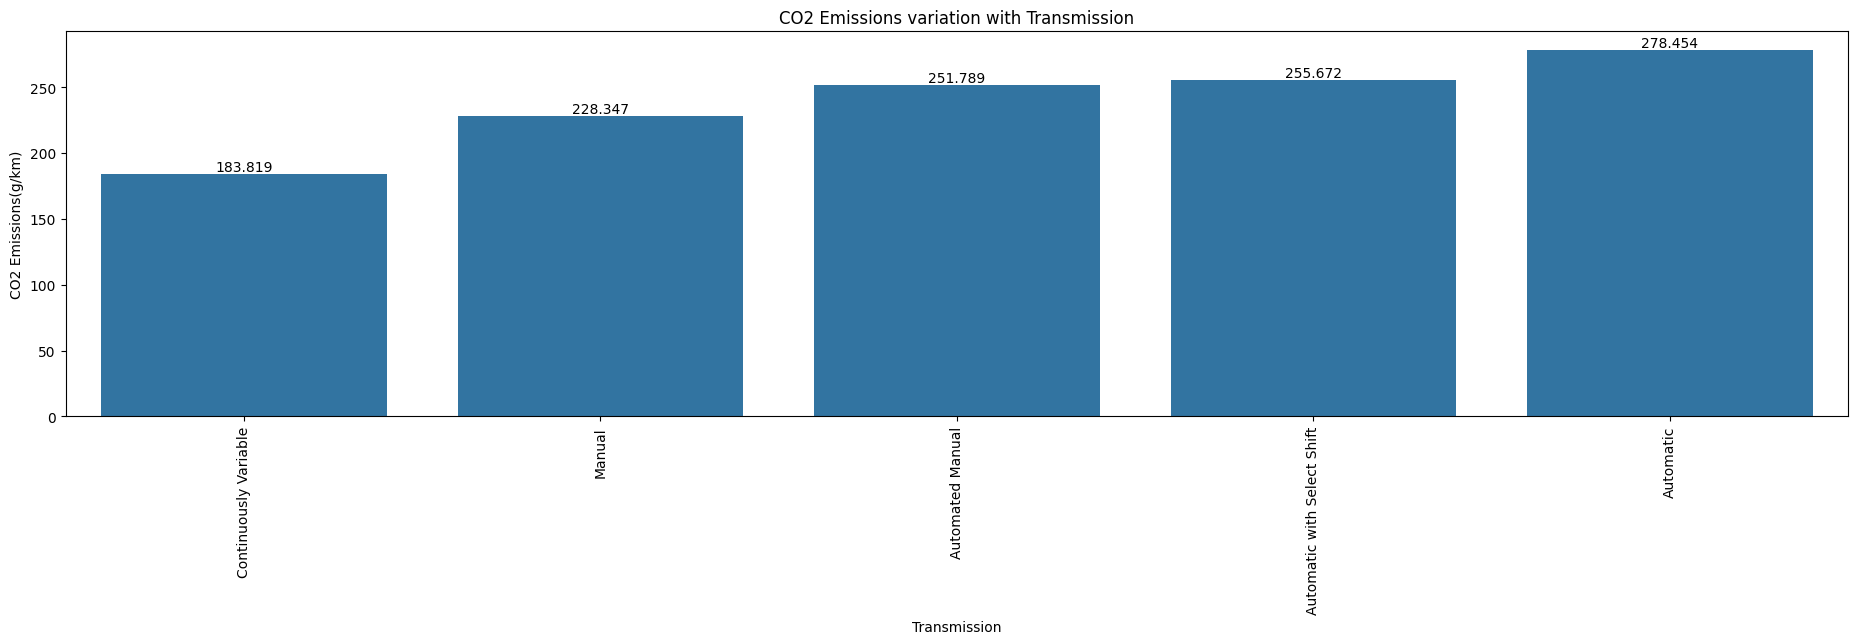

In [ ]:
plt.figure(figsize=(23,5))
figure10 = sns.barplot(data = df_co2_transmission, x = "Transmission",  y= "CO2 Emissions(g/km)")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Transmission")
plt.xlabel("Transmission")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure10.containers[0], fontsize=10)
plt.show()

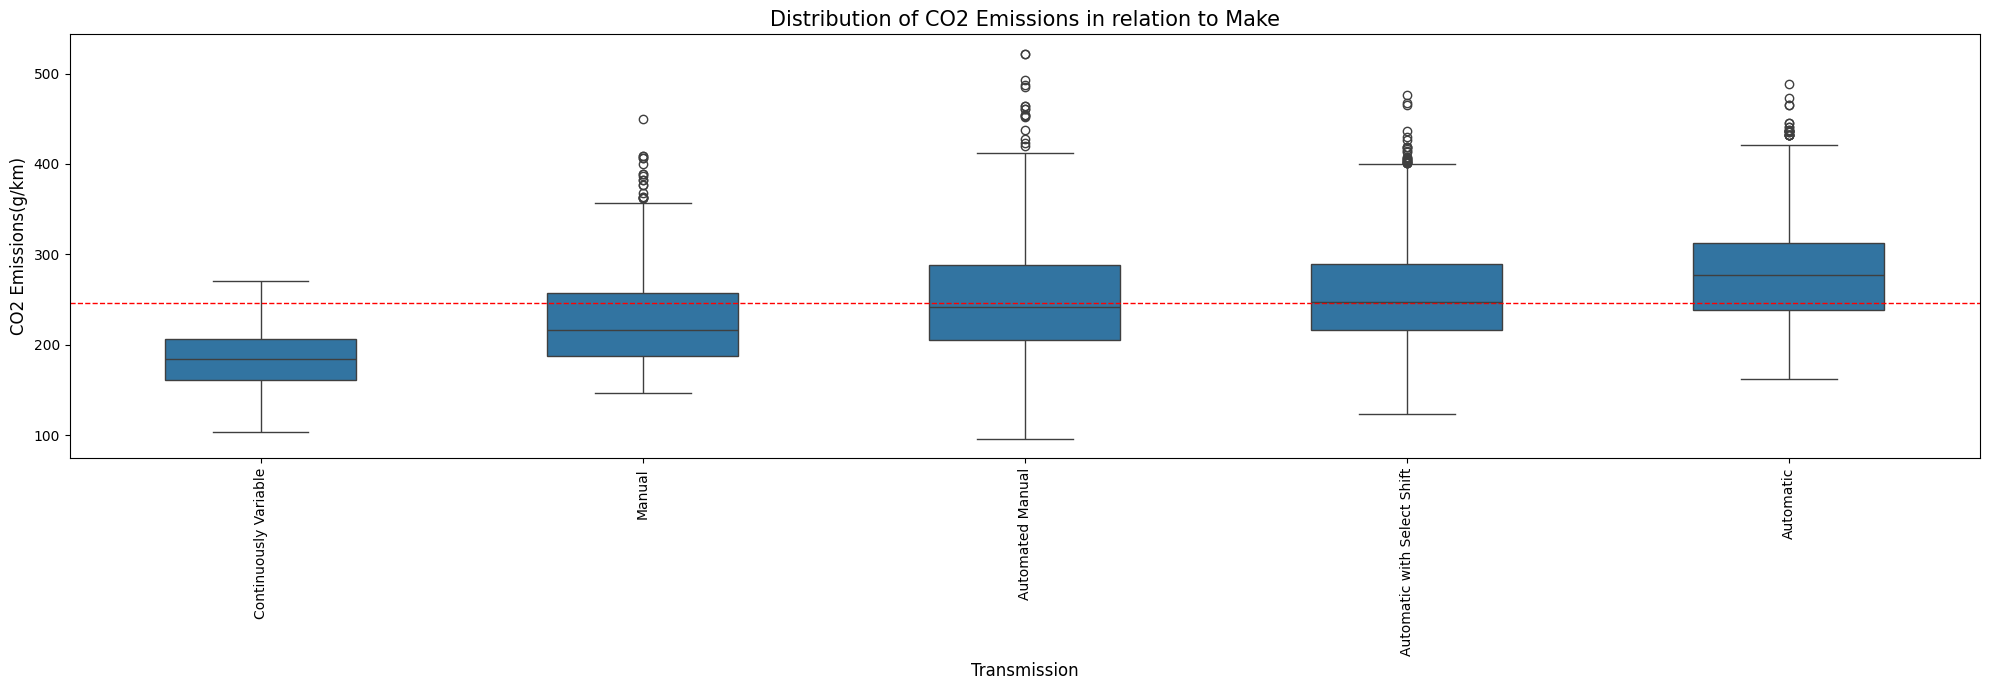

In [ ]:
plt.figure(figsize=(20,7))
order = df.groupby("Transmission")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Transmission", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Transmission", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

### <font color='green'> CO2 Emissions variation with Fuel Type </font>

In [ ]:
df_co2_fuel_type = df.groupby(['Fuel Type'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

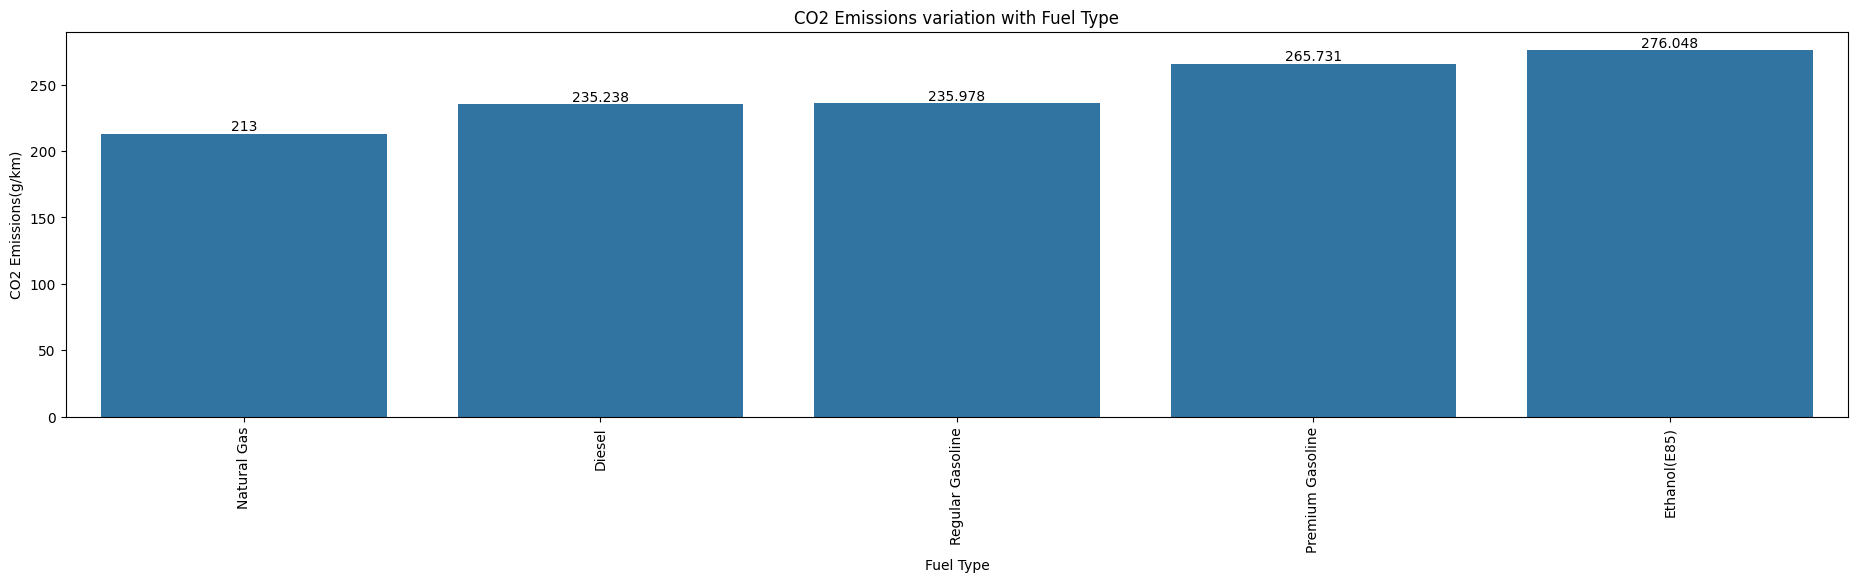

In [ ]:
plt.figure(figsize=(23,5))
figure11 = sns.barplot(data = df_co2_fuel_type, x = "Fuel Type",  y= "CO2 Emissions(g/km)")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure11.containers[0], fontsize=10)
plt.show()

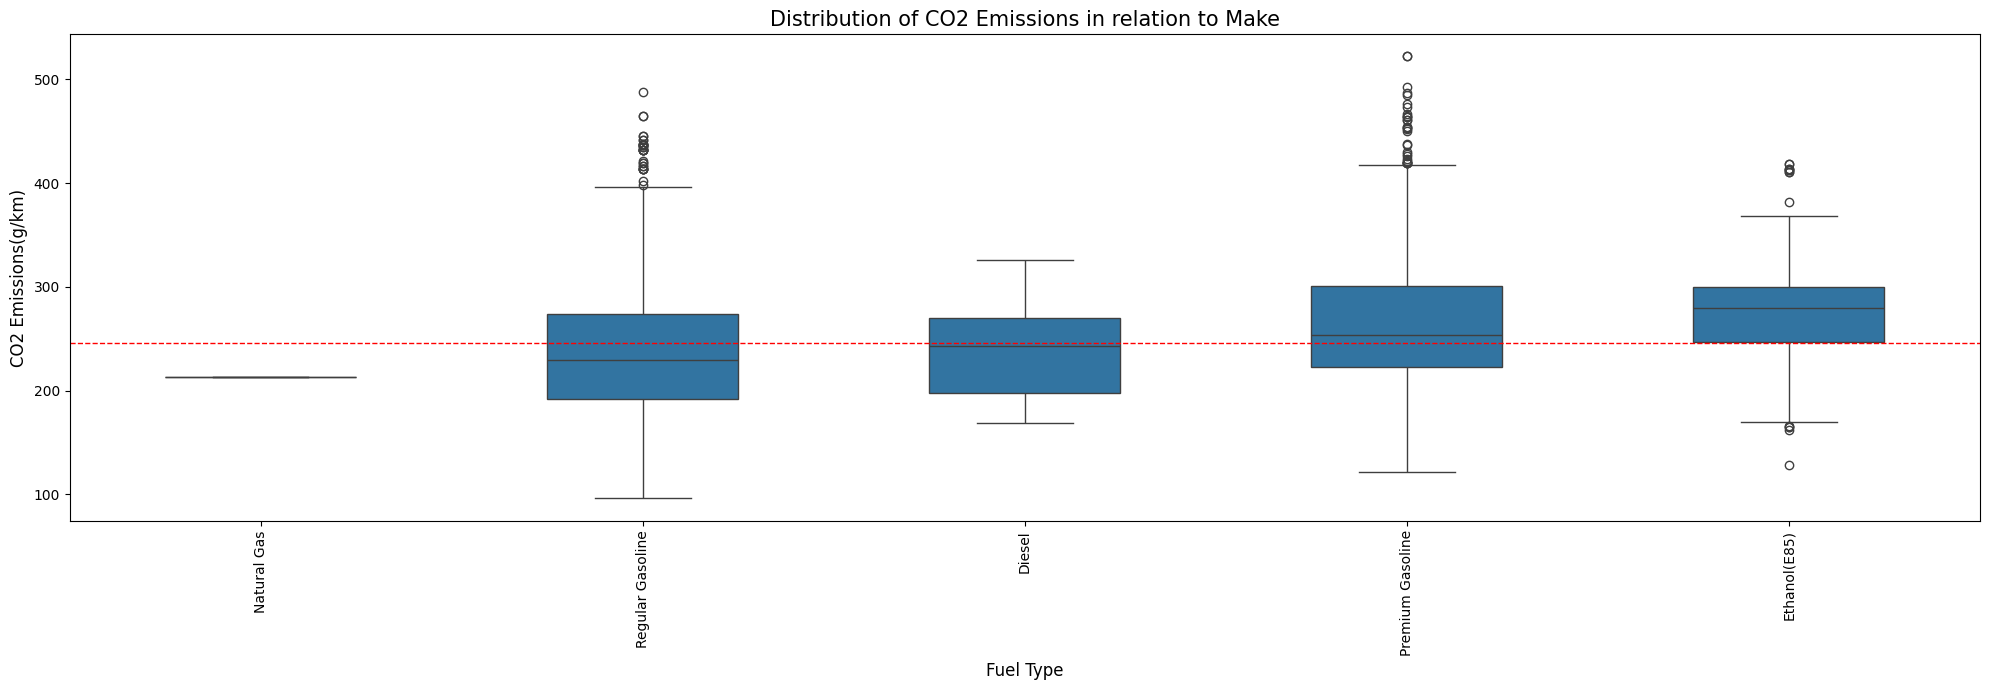

In [ ]:
plt.figure(figsize=(20,7))
order = df.groupby("Fuel Type")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Fuel Type", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

### <font color=red>Conclusion Of the EDA </font>
#### 1. There are total 42 types of car brand.
#### 2. There are total 2053 unique car model. These neither can be converted into any dummy variable nor it can be used for analysis. So we can drop this column.
#### 3. There are total 16 types of vehicle class basis on their gross vehicle weight rating (GVWR) and volume index. But there are no data available with exact GVWR or volume index value, so that we can categories the similar vehicle into a same group.
#### 4. The 27 type of transmission has been clubbed into 5 different transmission without taking the number of clutches into account, as they does not affect CO2 emissions.
#### 5. The 5 type of Fuel Types has been renamed so that it has some meaningful interpretation.
#### 6. We have only one data on natural gas. So we cannot predict anything using only one data. That's why we have to drop this row.


## <font color='red'> DATA CLEANING </font>

In [ ]:
# Check columns
print(df.columns.tolist())

# Dataset shape
print("Dataset shape:", df.shape)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']
Dataset shape: (6282, 12)

Missing values:
Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

Duplicate rows: 9


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (6273, 12)


In [ ]:
# Check fuel type distribution
print(df["Fuel Type"].value_counts())

# Remove Natural Gas
df = df[df["Fuel Type"] != "Natural Gas"].reset_index(drop=True)

print("\nFuel types after removing Natural Gas:")
print(df["Fuel Type"].value_counts())

Fuel Type
Regular Gasoline    3030
Premium Gasoline    2765
Ethanol(E85)         330
Diesel               147
Natural Gas            1
Name: count, dtype: int64

Fuel types after removing Natural Gas:
Fuel Type
Regular Gasoline    3030
Premium Gasoline    2765
Ethanol(E85)         330
Diesel               147
Name: count, dtype: int64


In [ ]:
features = [
    "Engine Size(L)",
    "Fuel Type",
    "Vehicle Class",
    "Cylinders",
    "Fuel Consumption Comb (L/100 km)"
]

target = "CO2 Emissions(g/km)"

# Keep required columns
df = df[features + [target]]

print(df.columns.tolist())

['Engine Size(L)', 'Fuel Type', 'Vehicle Class', 'Cylinders', 'Fuel Consumption Comb (L/100 km)', 'CO2 Emissions(g/km)']


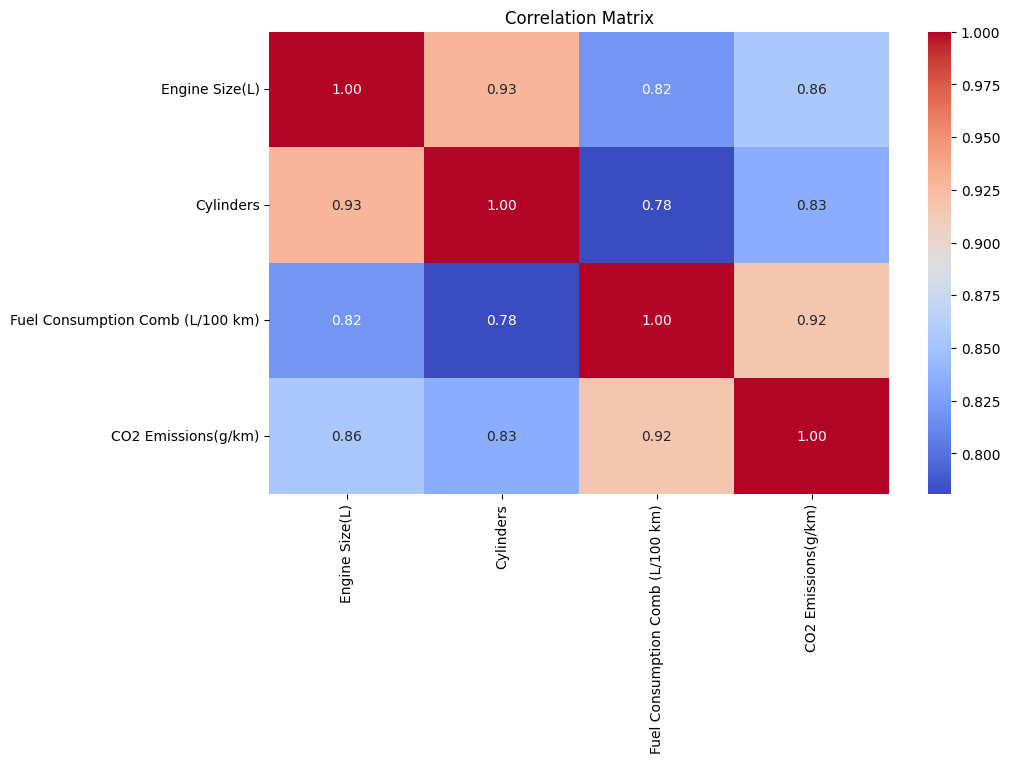

In [ ]:


# Numeric columns for correlation
numeric_columns = [
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption Comb (L/100 km)",
    "CO2 Emissions(g/km)"
]

df_correlation = df[numeric_columns]

# Correlation matrix
correlation = df_correlation.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

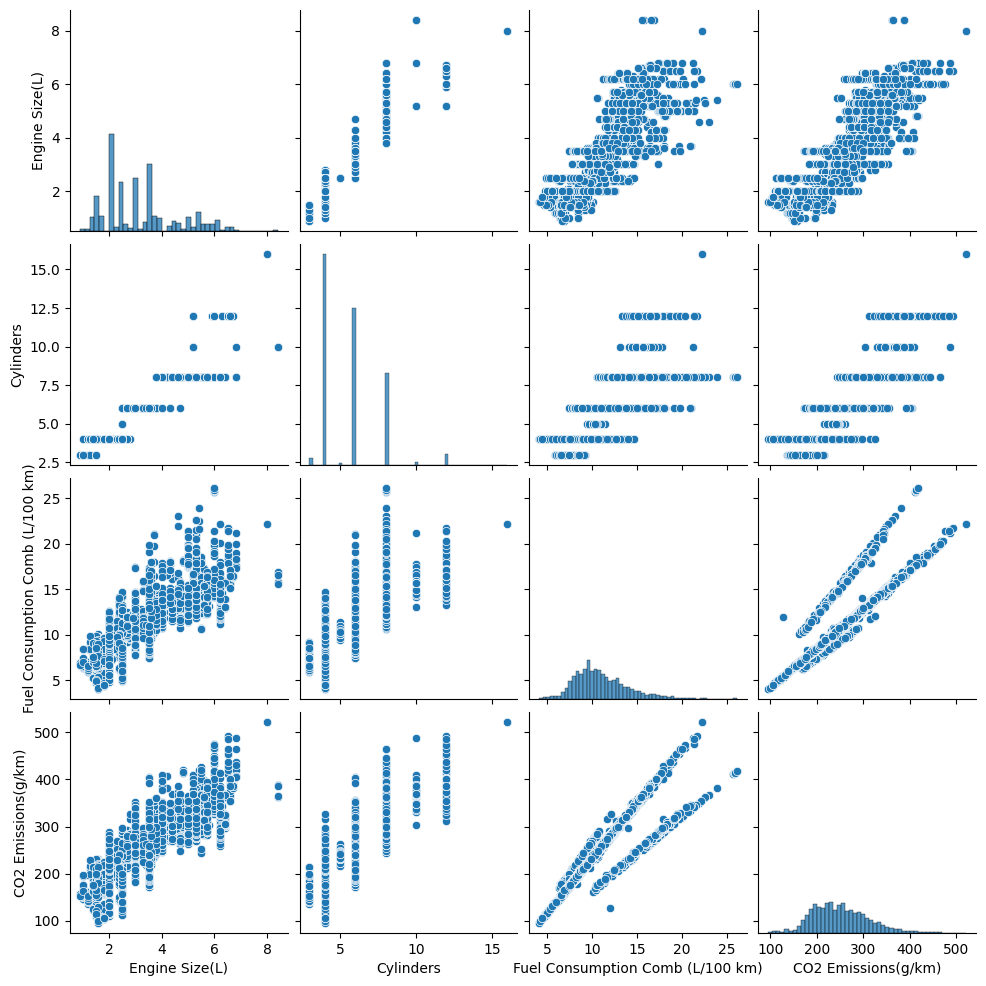

In [ ]:
sns.pairplot(df_correlation)
plt.show()

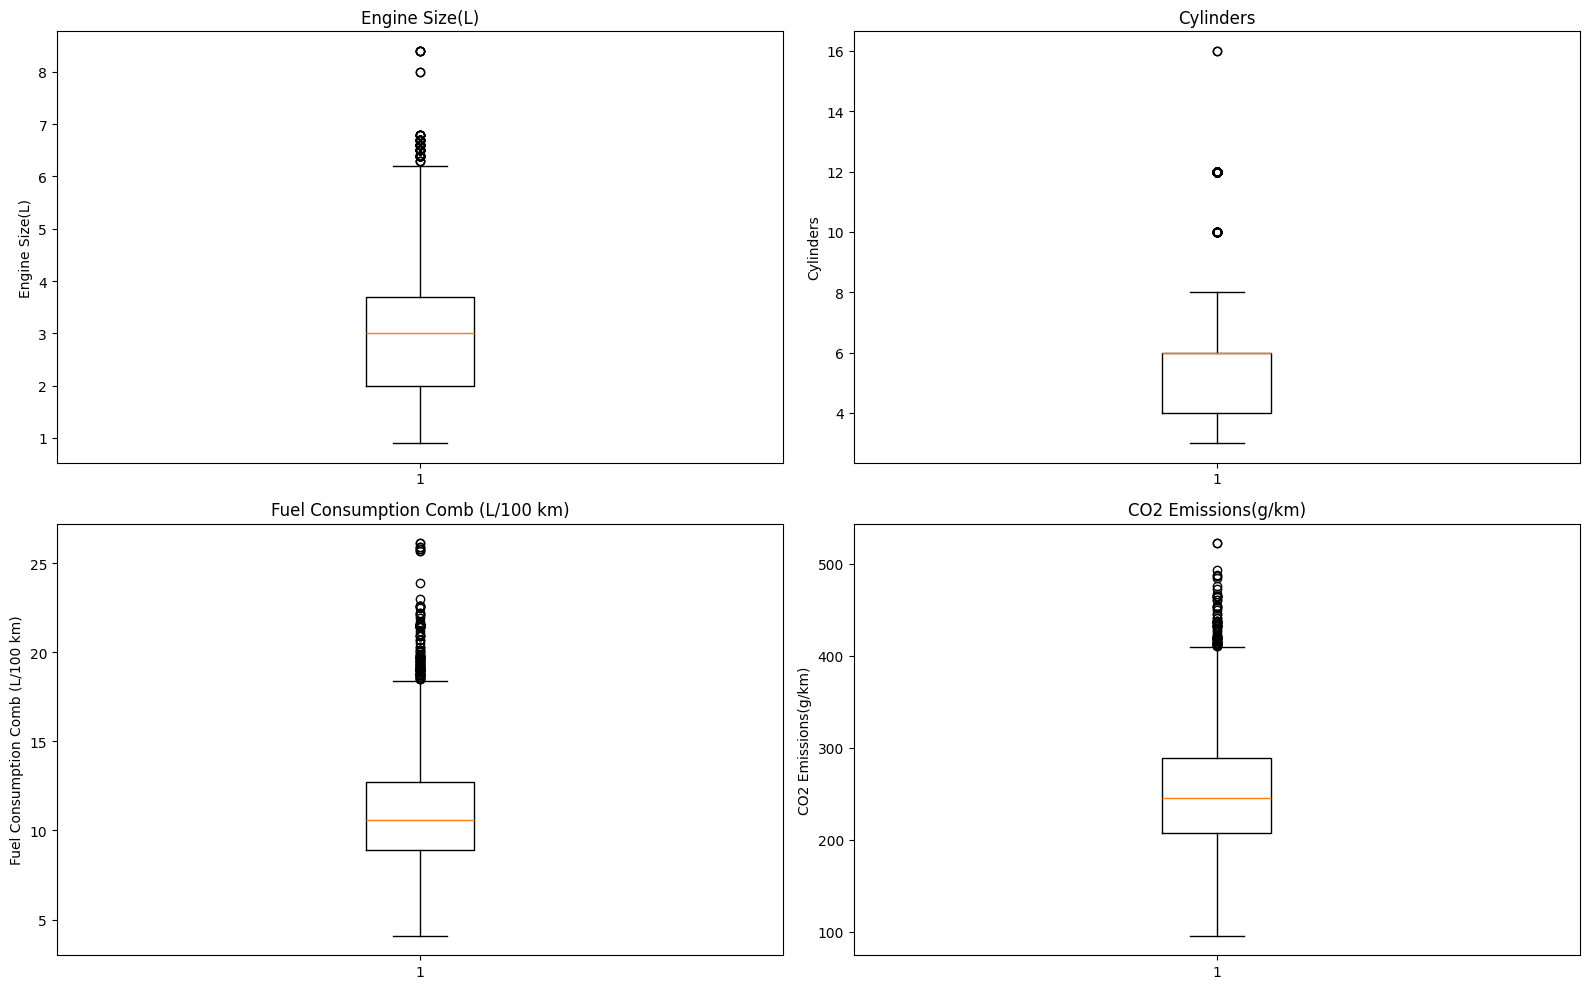

In [ ]:
plt.figure(figsize=(16, 10))

for i, column in enumerate(df_correlation.columns):
    plt.subplot(2, 2, i + 1)
    plt.title(column)
    plt.boxplot(df_correlation[column].dropna())
    plt.ylabel(column)

plt.tight_layout()
plt.show()

In [ ]:


z = np.abs(stats.zscore(df_correlation))

# Keep rows where all Z-scores are below 3
df_clean = df[(z < 3).all(axis=1)].copy()

print("Original rows:", len(df))
print("Rows after removing outliers:", len(df_clean))
print("Outliers removed:", len(df) - len(df_clean))

Original rows: 6272
Rows after removing outliers: 6065
Outliers removed: 207


In [ ]:
print(df_clean.head())
print(df_clean.tail())

print("\nDataset information:")
print(df_clean.info())

print("\nSummary statistics:")
print(df_clean.describe().T)

   Engine Size(L)         Fuel Type Vehicle Class  Cylinders  \
0             2.0  Premium Gasoline       COMPACT          4   
1             2.4  Premium Gasoline       COMPACT          4   
2             1.5  Premium Gasoline       COMPACT          4   
3             3.5  Premium Gasoline   SUV - SMALL          6   
4             3.5  Premium Gasoline   SUV - SMALL          6   

   Fuel Consumption Comb (L/100 km)  CO2 Emissions(g/km)  
0                               8.5                  196  
1                               9.6                  221  
2                               5.9                  136  
3                              11.1                  255  
4                              10.6                  244  
      Engine Size(L)         Fuel Type   Vehicle Class  Cylinders  \
6267             2.0  Premium Gasoline     SUV - SMALL          4   
6268             2.0  Premium Gasoline     SUV - SMALL          4   
6269             2.0  Premium Gasoline     SUV - SMALL

In [ ]:
print(df_clean["Fuel Type"].value_counts())

Fuel Type
Regular Gasoline    3009
Premium Gasoline    2620
Ethanol(E85)         289
Diesel               147
Name: count, dtype: int64


In [ ]:
# Features
X = df_clean[features]

# Target
y = df_clean[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6065, 5)
y shape: (6065,)


In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# -----------------------------------------
# Features
# -----------------------------------------

categorical_features = [
    "Fuel Type",
    "Vehicle Class"
]

numeric_features = [
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption Comb (L/100 km)"
]

# -----------------------------------------
# Preprocessor
# -----------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# -----------------------------------------
# Fit ONLY on training data
# -----------------------------------------

X_train_encoded = preprocessor.fit_transform(X_train)

# Transform validation and test
X_val_encoded = preprocessor.transform(X_val)
X_test_encoded = preprocessor.transform(X_test)

# Get the correct encoded column names
encoded_columns = preprocessor.get_feature_names_out()

print("Train encoded shape:", X_train_encoded.shape)
print("Validation encoded shape:", X_val_encoded.shape)
print("Test encoded shape:", X_test_encoded.shape)
print("Number of encoded columns:", len(encoded_columns))

Train encoded shape: (3639, 23)
Validation encoded shape: (1213, 23)
Test encoded shape: (1213, 23)
Number of encoded columns: 23


In [ ]:
# -----------------------------------------
# Create encoded Train DataFrame
# -----------------------------------------

train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns
)

train_encoded[target] = y_train.reset_index(drop=True)
train_encoded["Dataset"] = "Train"


# -----------------------------------------
# Create encoded Validation DataFrame
# -----------------------------------------

val_encoded = pd.DataFrame(
    X_val_encoded,
    columns=encoded_columns
)

val_encoded[target] = y_val.reset_index(drop=True)
val_encoded["Dataset"] = "Validation"


# -----------------------------------------
# Create encoded Test DataFrame
# -----------------------------------------

test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns
)

test_encoded[target] = y_test.reset_index(drop=True)
test_encoded["Dataset"] = "Test"

In [ ]:
# -----------------------------------------
# Combine all datasets
# -----------------------------------------

all_data = pd.concat(
    [
        train_encoded,
        val_encoded,
        test_encoded
    ],
    ignore_index=True
)

# -----------------------------------------
# Save final CSV
# -----------------------------------------

all_data.to_csv(
    "co2_emission_final_encoded_dataset.csv",
    index=False
)

print("CSV saved successfully!")

print("\nDataset distribution:")
print(all_data["Dataset"].value_counts())

print("\nFinal shape:")
print(all_data.shape)

print("\nFinal columns:")
print(all_data.columns.tolist())

CSV saved successfully!

Dataset distribution:
Dataset
Train         3639
Validation    1213
Test          1213
Name: count, dtype: int64

Final shape:
(6065, 25)

Final columns:
['num__Engine Size(L)', 'num__Cylinders', 'num__Fuel Consumption Comb (L/100 km)', 'cat__Fuel Type_Diesel', 'cat__Fuel Type_Ethanol(E85)', 'cat__Fuel Type_Premium Gasoline', 'cat__Fuel Type_Regular Gasoline', 'cat__Vehicle Class_COMPACT', 'cat__Vehicle Class_FULL-SIZE', 'cat__Vehicle Class_MID-SIZE', 'cat__Vehicle Class_MINICOMPACT', 'cat__Vehicle Class_MINIVAN', 'cat__Vehicle Class_PICKUP TRUCK - SMALL', 'cat__Vehicle Class_PICKUP TRUCK - STANDARD', 'cat__Vehicle Class_SPECIAL PURPOSE VEHICLE', 'cat__Vehicle Class_STATION WAGON - MID-SIZE', 'cat__Vehicle Class_STATION WAGON - SMALL', 'cat__Vehicle Class_SUBCOMPACT', 'cat__Vehicle Class_SUV - SMALL', 'cat__Vehicle Class_SUV - STANDARD', 'cat__Vehicle Class_TWO-SEATER', 'cat__Vehicle Class_VAN - CARGO', 'cat__Vehicle Class_VAN - PASSENGER', 'CO2 Emissions(g/km)